In [3]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 80.7 MB/s eta 0:00:00


In [6]:
# Cell 1 — Install & Download Dataset
!pip install streamlit pyngrok -q

import urllib.request
import zipfile

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
urllib.request.urlretrieve(url, "UCI_HAR.zip")

with zipfile.ZipFile("UCI_HAR.zip", 'r') as z:
    z.extractall(".")

print("✅ Dataset ready!")

✅ Dataset ready!


In [8]:
# Cell 2 — Train all models
%run train.py

  24AI636 — HAR Deep Learning System
  CNN + LSTM Hybrid (DeepConvLSTM)
📦 Loading UCI HAR Dataset...
   Train: (7352, 128, 9), Test: (2947, 128, 9)
   Classes: [0 1 2 3 4 5]

🔧 Applying data augmentation...
   Augmented train size: 9557

🔬 Hyperparameter Search...
   filters= 32 | kernel=3 | lstm= 50 | drop=0.2 → val_acc=92.53%
   filters= 64 | kernel=3 | lstm=100 | drop=0.3 → val_acc=93.48%
   filters= 64 | kernel=5 | lstm=100 | drop=0.4 → val_acc=93.59%
   filters=128 | kernel=3 | lstm=100 | drop=0.3 → val_acc=94.27%
   filters=128 | kernel=5 | lstm=128 | drop=0.5 → val_acc=93.21%

   🏆 Best config: {'filters': 128, 'kernel_size': 3, 'lstm_units': 100, 'dropout': 0.3} → 94.27%
   ✅ Saved: outputs/hyperparameter_table.png

🚀 Training all models for comparison...

─── MLP ───
Epoch 1/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7531 - loss: 0.6973 - val_accuracy: 0.8575 - val_loss: 0.4276 - learning_rate: 0.0010
Epoch 2/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accura

<Figure size 640x480 with 0 Axes>

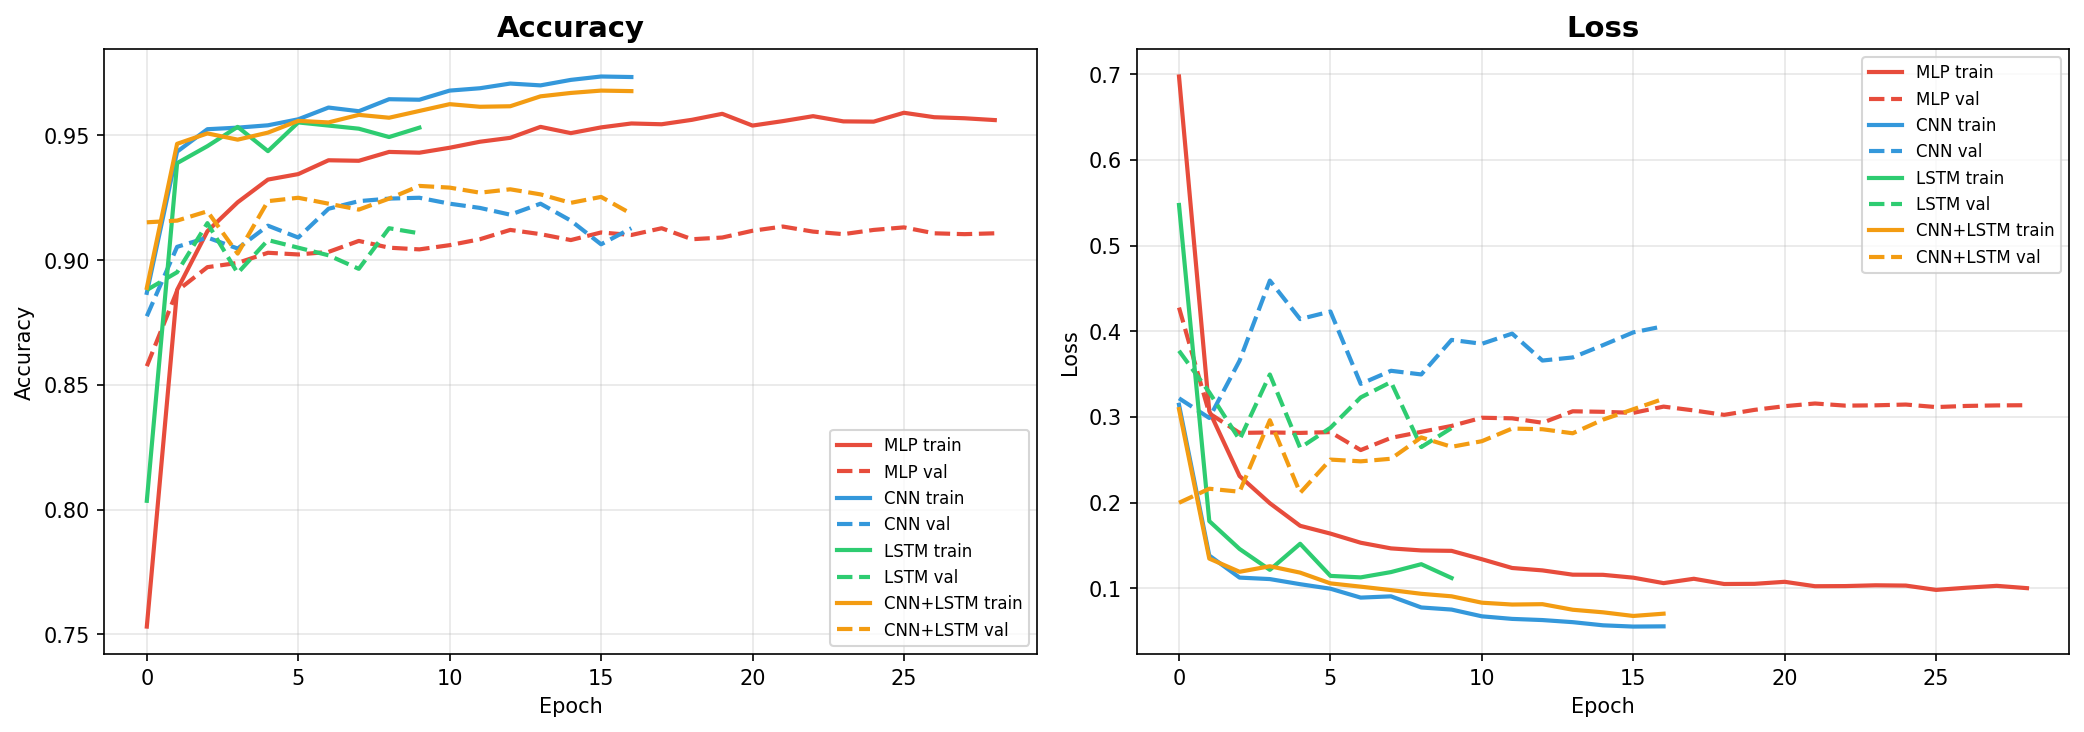

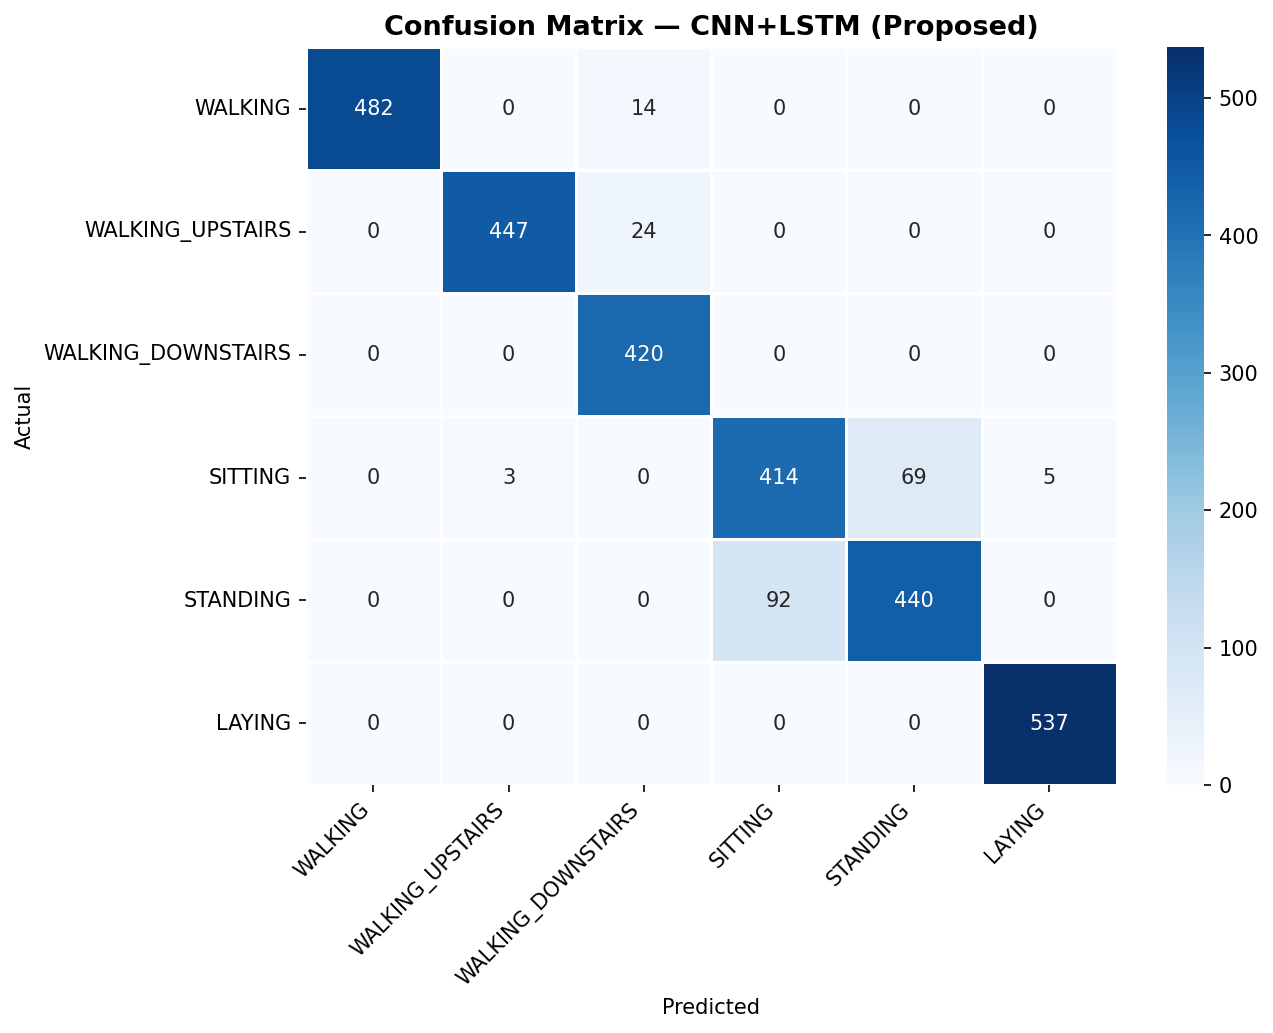

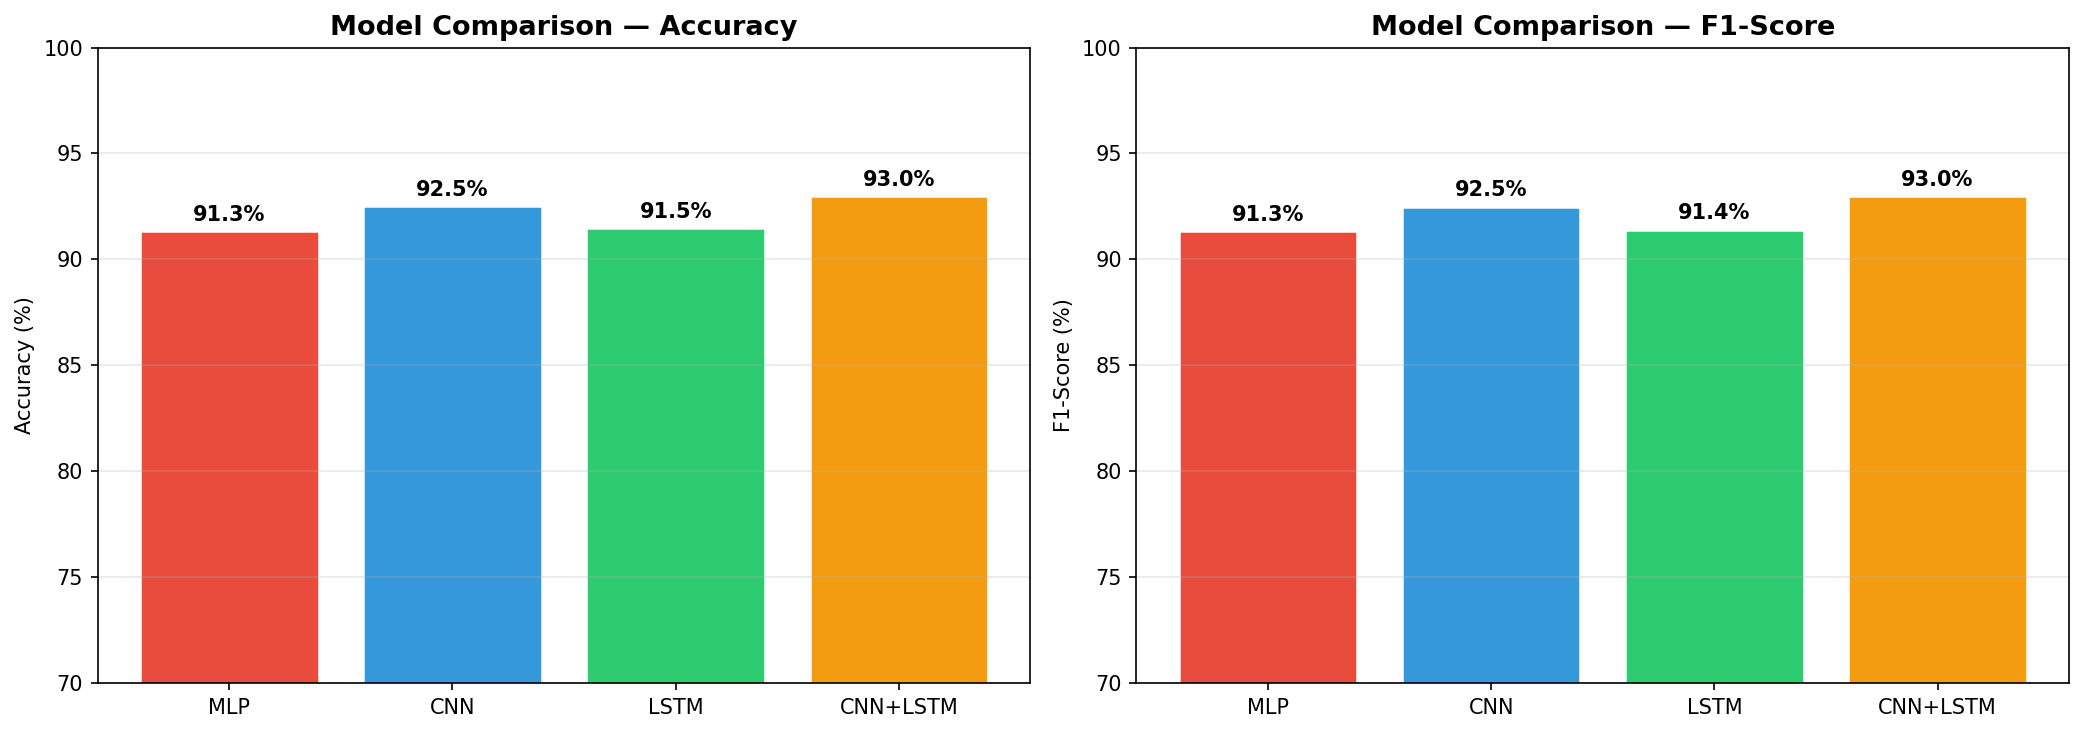

In [9]:
# Cell 3 — Display plots inline
from IPython.display import Image, display

display(Image('outputs/training_curves.png'))
display(Image('outputs/confusion_matrix.png'))
display(Image('outputs/model_comparison.png'))

In [17]:
# Cell 4 — Streamlit via ngrok (paste YOUR token)
!pip install pyngrok -q
from pyngrok import ngrok
import subprocess, threading, time

ngrok.set_auth_token("3BtYbQoUIR3ZpSGOWuExsLDynC3_5mjP893SRyUAXSzS1Wjov")  # ← replace this

def run():
    subprocess.run(["streamlit", "run", "app.py",
                    "--server.port", "8501",
                    "--server.headless", "true"])

threading.Thread(target=run, daemon=True).start()
time.sleep(6)

url = ngrok.connect(8501)
print(f"🌐 Live app: {url}")

🌐 Live app: NgrokTunnel: "https://synclinal-alexis-nonprofit.ngrok-free.dev" -> "http://localhost:8501"
